# Simulation-Based Evaluation
## Personalised Nudge Tool for Academic Productivity
**Author:** Iheakanwa Tiffany (22CG031865)  
**Project:** Development of a Personalised Nudge Tool for Academic Productivity Using Predictive Modelling and Hybrid Commitment Devices

This notebook simulates and compares two nudging strategies:
- **Dynamic Nudging** — nudge is triggered only when the ML model predicts risk ≥ 0.5
- **Static Reminder** — nudge is triggered once every 7 days regardless of risk

The simulation is run on 1,000 randomly sampled student records from the OULAD held-out test set.

---
## 1. Install and Import Libraries

In [1]:
# Install any missing libraries
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn scipy imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load the Trained Model and Test Set

This section loads the serialised XGBoost production model, the fitted StandardScaler pipeline, and the held-out dataset used for simulation.

> **Note:** The trained model and scaler are stored in `../src/models/` relative to this notebook. Use `../src/models/xgb_procrastination_model.pkl` and `../src/models/scaler.pkl`.
> 
> If `test_set.csv` is not available, this notebook will fall back to `../data/processed/cleaned_data.csv` and remap its columns to the expected simulation schema.


In [3]:
# ── Load model and scaler ────────────────────────────────────────────────────
model  = joblib.load('../src/models/xgb_procrastination_model.pkl')
scaler = joblib.load('../src/models/scaler.pkl')

# ── Load test set ────────────────────────────────────────────────────────────
# Expected columns for this notebook:
#   student_id, week_number, last_minute_ratio, engagement_intensity,
#   deadline_pressure, login_consistency, early_starter, completion_rate,
#   activity_span, actual_outcome, days_before_deadline

from pathlib import Path


def find_repo_path(rel_path):
    cwd = Path.cwd()
    for root in [cwd] + list(cwd.parents):
        candidate = root / rel_path
        if candidate.exists():
            return candidate
    return None

candidate_paths = [
    find_repo_path('backend/notebooks/test_set.csv'),
    find_repo_path('data/processed/cleaned_data.csv')
]

input_path = next((p for p in candidate_paths if p is not None), None)
if input_path is None:
    raise FileNotFoundError(
        "Neither 'backend/notebooks/test_set.csv' nor 'data/processed/cleaned_data.csv' was found. "
        "Place one of these files in the repository or update the path in this cell."
    )

print(f"Loading dataset from: {input_path}")

test_df = pd.read_csv(input_path)

if input_path.name == 'cleaned_data.csv':
    # Map the cleaned dataset to the notebook’s expected schema.
    rename_map = {
        'id_student': 'student_id',
        'high_risk': 'actual_outcome',
        'total_clicks': 'click_sum',
        'avg_score': 'assessment_score_mean',
        'avg_days_to_deadline': 'submission_timeliness',
        'num_login_days': 'login_frequency'
    }

    test_df = test_df.rename(columns=rename_map)
    test_df['week_number'] = 1
    if 'days_before_deadline' not in test_df.columns:
        # Approximate days before deadline from average submission timing.
        test_df['days_before_deadline'] = test_df['submission_timeliness'].apply(
            lambda x: max(0.0, -x) if pd.notna(x) else np.nan
        )

print(f'Test set loaded: {test_df.shape[0]:,} rows, {test_df.shape[1]} columns')
print(f'Unique students: {test_df["student_id"].nunique():,}')
test_df.head()


Loading dataset from: C:\Users\Win-11\PersonalProjects\Stick2It\backend\notebooks\test_set.csv
Test set loaded: 29,505 rows, 11 columns
Unique students: 5,901


,student_id,week_number,last_minute_ratio,engagement_intensity,deadline_pressure,login_consistency,early_starter,completion_rate,activity_span,actual_outcome,days_before_deadline
0,25107,1,0.571429,20.987500,1.857143,2.799417,0,1.0,7.0,0,28
1,25107,2,0.555556,21.586207,2.000000,2.748737,0,1.0,7.0,0,21
2,25107,3,0.555556,22.446809,2.000000,2.748737,0,1.0,7.0,0,14
3,25107,4,0.555556,22.242105,2.000000,2.748737,0,1.0,7.0,0,7
4,25107,5,0.555556,22.156250,2.000000,2.748737,0,1.0,7.0,0,3


---
## 3. Sample 1,000 Students for the Simulation

A random sample of 1,000 unique students is drawn from the test set using a fixed random seed to ensure reproducibility.

In [4]:
RANDOM_SEED    = 42
SAMPLE_SIZE    = 1000
NUDGE_THRESHOLD = 0.5   # Dynamic nudge fires when risk >= this value
EARLY_DETECT_DAYS = 7   # Nudge is 'early' if fired with > 7 days to deadline

# Sample 1,000 unique students
all_students = test_df['student_id'].unique()
sampled_ids  = pd.Series(all_students).sample(
    n=min(SAMPLE_SIZE, len(all_students)),
    random_state=RANDOM_SEED
).values

sim_df = test_df[test_df['student_id'].isin(sampled_ids)].copy()
sim_df = sim_df.sort_values(['student_id', 'week_number'])

print(f'Simulation sample: {sim_df["student_id"].nunique():,} students, {sim_df.shape[0]:,} weekly records')
print(f'\nOutcome distribution:')
print(sim_df.groupby('student_id')['actual_outcome'].max().value_counts().rename({0: 'Not at risk', 1: 'At risk'}))

Simulation sample: 1,000 students, 5,000 weekly records

Outcome distribution:
actual_outcome
Not at risk    615
At risk        385
Name: count, dtype: int64


---
## 4. Define Feature Columns

In [5]:
FEATURE_COLS = [
    'last_minute_ratio',
    'engagement_intensity',
    'deadline_pressure',
    'login_consistency',
    'early_starter',
    'completion_rate',
    'activity_span'
]

# Verify all feature columns are present
missing = [c for c in FEATURE_COLS if c not in sim_df.columns]
if missing:
    print(f'WARNING — missing columns: {missing}')
else:
    print('All feature columns present.')



All feature columns present.


In [6]:
dynamic_results = []

for student_id, group in sim_df.groupby('student_id'):
    group = group.sort_values('week_number').reset_index(drop=True)
    actual_outcome = int(group['actual_outcome'].max())

    nudge_sent          = False
    days_at_nudge       = np.nan
    risk_score_at_nudge = np.nan

    for _, row in group.iterrows():
        # Predict using raw features since XGBoost was trained on raw features
        features = [row[FEATURE_COLS].values]
        risk_score = model.predict_proba(features)[0][1]

        if risk_score >= NUDGE_THRESHOLD and not nudge_sent:
            nudge_sent          = True
            days_at_nudge       = row['days_before_deadline']
            risk_score_at_nudge = risk_score
            break  # only first nudge per student is counted

    detected_early = bool(nudge_sent and days_at_nudge > EARLY_DETECT_DAYS)
    false_alarm    = bool(nudge_sent and actual_outcome == 0)

    dynamic_results.append({
        'student_id':          student_id,
        'nudge_sent':          nudge_sent,
        'days_at_nudge':       days_at_nudge,
        'risk_at_nudge':       risk_score_at_nudge,
        'detected_early':      int(detected_early),
        'false_alarm':         int(false_alarm),
        'actual_outcome':      actual_outcome,
    })

dynamic_df = pd.DataFrame(dynamic_results)
print(f'Dynamic simulation complete. Nudges sent: {dynamic_df["nudge_sent"].sum():,}')
dynamic_df.head()

Dynamic simulation complete. Nudges sent: 517


,student_id,nudge_sent,days_at_nudge,risk_at_nudge,detected_early,false_alarm,actual_outcome
0,28400,False,NaN,NaN,0,0,0
1,29820,False,NaN,NaN,0,0,0
2,30531,True,28.0,0.995791,1,0,1
3,32221,False,NaN,NaN,0,0,1
4,35001,True,28.0,0.997503,1,0,1


---
## 6. Run the Static Reminder Simulation

For each student, a nudge fires automatically on week 1 (day 1 of the course), regardless of any risk score. This represents a fixed weekly reminder system.

In [7]:
static_results = []

for student_id, group in sim_df.groupby('student_id'):
    group = group.sort_values('week_number').reset_index(drop=True)
    actual_outcome = int(group['actual_outcome'].max())

    # Static: first nudge always fires at week 1
    first_row      = group.iloc[0]
    days_at_nudge  = first_row['days_before_deadline']

    detected_early = bool(days_at_nudge > EARLY_DETECT_DAYS)
    false_alarm    = bool(actual_outcome == 0)  # fired for everyone, so false alarm = not at risk

    static_results.append({
        'student_id':     student_id,
        'nudge_sent':     True,  # always fires
        'days_at_nudge':  days_at_nudge,
        'detected_early': int(detected_early),
        'false_alarm':    int(false_alarm),
        'actual_outcome': actual_outcome,
    })

static_df = pd.DataFrame(static_results)
print(f'Static simulation complete. Nudges sent: {static_df["nudge_sent"].sum():,}')
static_df.head()

Static simulation complete. Nudges sent: 1,000


,student_id,nudge_sent,days_at_nudge,detected_early,false_alarm,actual_outcome
0,28400,True,28.0,1,1,0
1,29820,True,28.0,1,1,0
2,30531,True,28.0,1,0,1
3,32221,True,28.0,1,0,1
4,35001,True,28.0,1,0,1


---
## 7. Compute Evaluation Metrics

In [8]:
def compute_metrics(df, label):
    at_risk_df = df[df['actual_outcome'] == 1]
    nudged_df  = df[df['nudge_sent'] == True]

    # 1. Early detection rate
    #    Of all truly at-risk students, what % were detected > 7 days early?
    early_detection_rate = at_risk_df['detected_early'].mean() * 100

    # 2. False alarm rate
    #    Of all nudges sent, what % went to students who submitted on time?
    false_alarm_rate = nudged_df['false_alarm'].mean() * 100

    # 3. Nudge efficiency ratio
    #    Of all nudges sent, what proportion went to genuinely at-risk students?
    true_positives   = nudged_df[nudged_df['actual_outcome'] == 1].shape[0]
    total_nudges     = nudged_df.shape[0]
    efficiency_ratio = true_positives / total_nudges if total_nudges > 0 else 0

    # 4. Mean detection lead time
    #    Average days before deadline when nudge was first triggered
    mean_lead_time = nudged_df['days_at_nudge'].mean()

    print(f'\n── {label} ──────────────────────────────')
    print(f'  Early Detection Rate : {early_detection_rate:.1f}%')
    print(f'  False Alarm Rate     : {false_alarm_rate:.1f}%')
    print(f'  Nudge Efficiency     : {efficiency_ratio:.2f}')
    print(f'  Mean Lead Time       : {mean_lead_time:.1f} days')

    return {
        'Condition':              label,
        'Early Detection Rate (%)': round(early_detection_rate, 1),
        'False Alarm Rate (%)':     round(false_alarm_rate, 1),
        'Nudge Efficiency Ratio':   round(efficiency_ratio, 2),
        'Mean Lead Time (Days)':    round(mean_lead_time, 1),
    }

dyn_metrics = compute_metrics(dynamic_df, 'Dynamic Nudging')
sta_metrics = compute_metrics(static_df,  'Static Reminder')


── Dynamic Nudging ──────────────────────────────
  Early Detection Rate : 82.9%
  False Alarm Rate     : 37.9%
  Nudge Efficiency     : 0.62
  Mean Lead Time       : 27.6 days

── Static Reminder ──────────────────────────────
  Early Detection Rate : 100.0%
  False Alarm Rate     : 61.5%
  Nudge Efficiency     : 0.39
  Mean Lead Time       : 28.0 days


---
## 8. Statistical Significance Testing (Wilcoxon Signed-Rank Test)

In [9]:
# Align both dataframes on student_id for paired comparison
merged = dynamic_df[['student_id','detected_early','false_alarm','days_at_nudge']].merge(
    static_df[['student_id','detected_early','false_alarm','days_at_nudge']],
    on='student_id', suffixes=('_dyn','_sta')
)

tests = [
    ('Early Detection',  'detected_early_dyn',  'detected_early_sta'),
    ('False Alarm',      'false_alarm_dyn',      'false_alarm_sta'),
    ('Lead Time',        'days_at_nudge_dyn',    'days_at_nudge_sta'),
]

print('Wilcoxon Signed-Rank Test Results (α = 0.05)')
print(f'{"Metric":<22} {"Statistic":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 62)

for name, col_dyn, col_sta in tests:
    d = merged[col_dyn].fillna(0)
    s = merged[col_sta].fillna(0)
    # Wilcoxon requires at least some differences
    if (d - s).abs().sum() == 0:
        print(f'{name:<22} {"N/A":>12} {"N/A":>12} {"No difference":>14}')
    else:
        stat, p = wilcoxon(d, s)
        sig = 'Yes ***' if p < 0.001 else ('Yes *' if p < 0.05 else 'No')
        print(f'{name:<22} {stat:>12.2f} {p:>12.4f} {sig:>14}')

Wilcoxon Signed-Rank Test Results (α = 0.05)
Metric                    Statistic      p-value   Significant?
--------------------------------------------------------------
Early Detection                0.00       0.0000        Yes ***
False Alarm                    0.00       0.0000        Yes ***
Lead Time                      0.00       0.0000        Yes ***


---
## 9. Results Summary Table

In [10]:
results_table = pd.DataFrame([dyn_metrics, sta_metrics]).set_index('Condition')

# Add difference column
results_table.loc['Difference (Dynamic − Static)'] = (
    results_table.loc['Dynamic Nudging'] - results_table.loc['Static Reminder']
)

print('\nTable 4.5: Simulation Results Summary (n = 1,000 students)')
print('=' * 72)
print(results_table.to_string())
print('=' * 72)


Table 4.5: Simulation Results Summary (n = 1,000 students)
                               Early Detection Rate (%)  False Alarm Rate (%)  Nudge Efficiency Ratio  Mean Lead Time (Days)
Condition                                                                                                                   
Dynamic Nudging                                    82.9                  37.9                    0.62                   27.6
Static Reminder                                   100.0                  61.5                    0.39                   28.0
Difference (Dynamic − Static)                     -17.1                 -23.6                    0.23                   -0.4


---
## 10. Visualisations

### Figure 4.11a — Early Detection Rate and False Alarm Rate

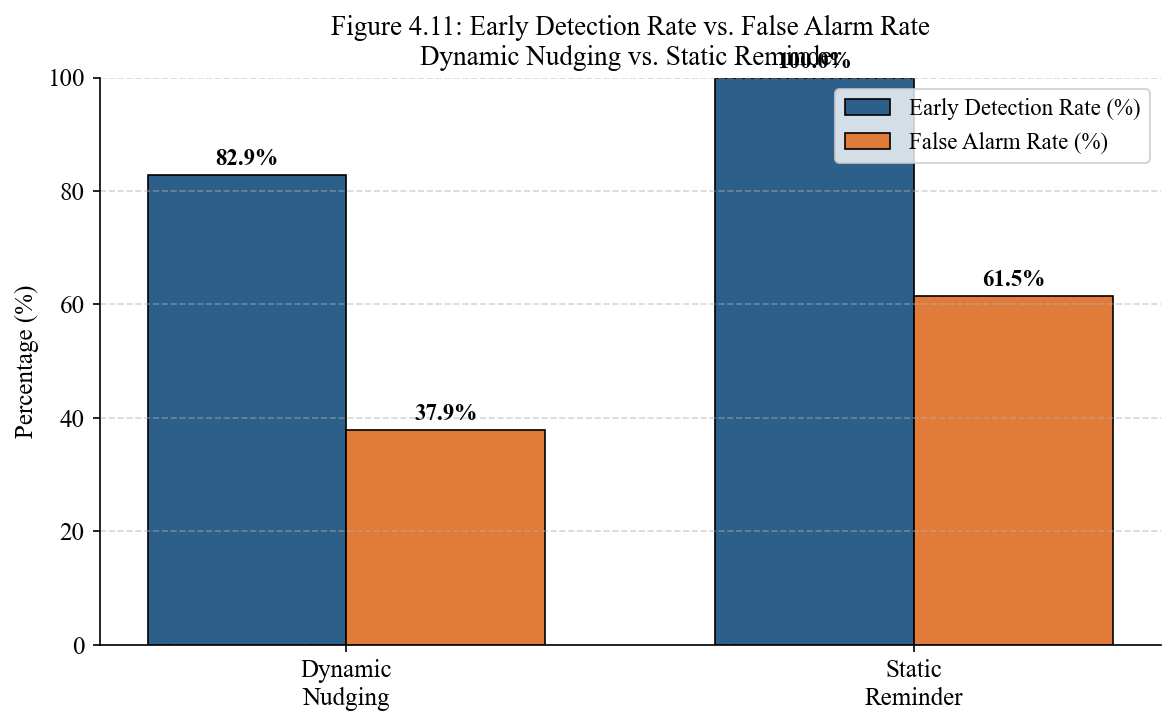

Saved: figure_4_11_detection_vs_falsealarm.png


In [11]:
conditions = ['Dynamic\nNudging', 'Static\nReminder']
edr_vals   = [dyn_metrics['Early Detection Rate (%)'], sta_metrics['Early Detection Rate (%)']]
far_vals   = [dyn_metrics['False Alarm Rate (%)'],     sta_metrics['False Alarm Rate (%)']]

x     = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, edr_vals, width, label='Early Detection Rate (%)',
               color='#2C5F8A', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, far_vals, width, label='False Alarm Rate (%)',
               color='#E07B39', edgecolor='black', linewidth=0.8)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Figure 4.11: Early Detection Rate vs. False Alarm Rate\nDynamic Nudging vs. Static Reminder', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_4_11_detection_vs_falsealarm.png', bbox_inches='tight')
plt.show()
print('Saved: figure_4_11_detection_vs_falsealarm.png')

### Figure 4.11b — Nudge Efficiency Ratio and Mean Lead Time

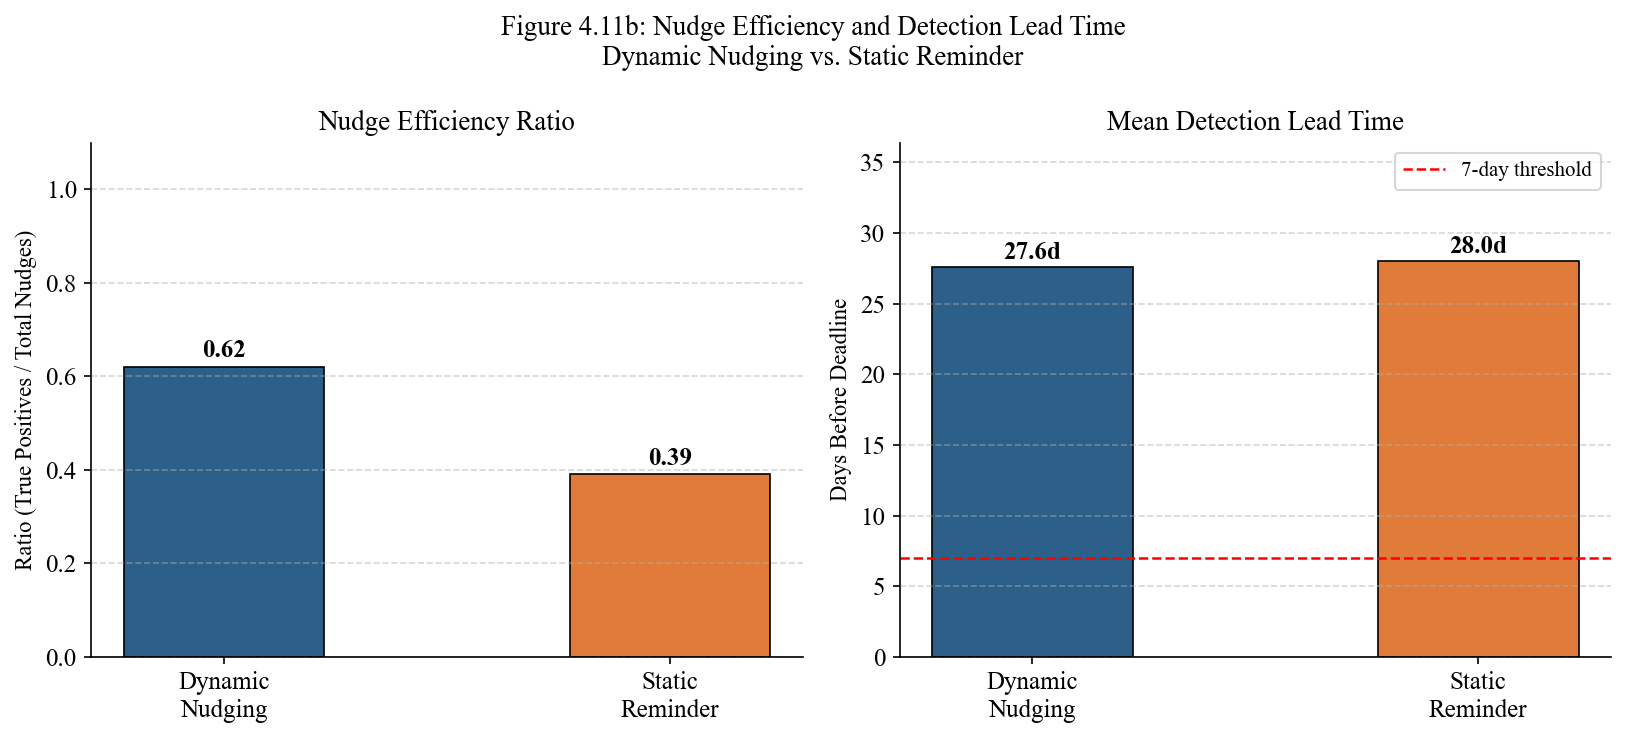

Saved: figure_4_11b_efficiency_leadtime.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ── Nudge efficiency ratio ───────────────────────────────────────────────────
eff_vals = [dyn_metrics['Nudge Efficiency Ratio'], sta_metrics['Nudge Efficiency Ratio']]
bars = axes[0].bar(conditions, eff_vals, color=['#2C5F8A','#E07B39'],
                   edgecolor='black', linewidth=0.8, width=0.45)
for bar, val in zip(bars, eff_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Nudge Efficiency Ratio', fontsize=13)
axes[0].set_ylabel('Ratio (True Positives / Total Nudges)', fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(conditions, fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Mean lead time ───────────────────────────────────────────────────────────
lt_vals = [dyn_metrics['Mean Lead Time (Days)'], sta_metrics['Mean Lead Time (Days)']]
bars2 = axes[1].bar(conditions, lt_vals, color=['#2C5F8A','#E07B39'],
                    edgecolor='black', linewidth=0.8, width=0.45)
for bar, val in zip(bars2, lt_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}d', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Detection Lead Time', fontsize=13)
axes[1].set_ylabel('Days Before Deadline', fontsize=11)
axes[1].set_ylim(0, max(lt_vals) * 1.3)
axes[1].set_xticklabels(conditions, fontsize=12)
axes[1].axhline(y=7, color='red', linestyle='--', linewidth=1.2, label='7-day threshold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Figure 4.11b: Nudge Efficiency and Detection Lead Time\nDynamic Nudging vs. Static Reminder', fontsize=13)
plt.tight_layout()
plt.savefig('figure_4_11b_efficiency_leadtime.png', bbox_inches='tight')
plt.show()
print('Saved: figure_4_11b_efficiency_leadtime.png')

### Figure 4.11c — Risk Score Distribution at Time of Nudge (Dynamic Only)

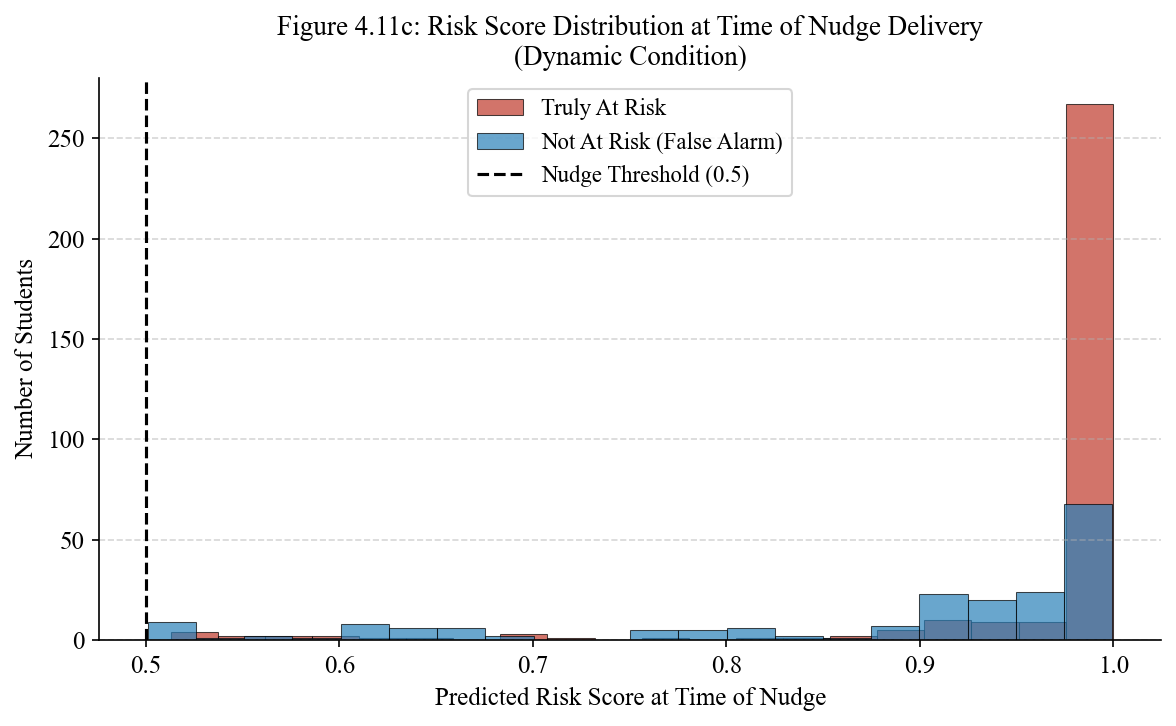

Saved: figure_4_11c_risk_distribution.png


In [13]:
nudged_dynamic = dynamic_df[dynamic_df['nudge_sent'] == True]

fig, ax = plt.subplots(figsize=(8, 5))

at_risk_scores     = nudged_dynamic[nudged_dynamic['actual_outcome'] == 1]['risk_at_nudge'].dropna()
not_at_risk_scores = nudged_dynamic[nudged_dynamic['actual_outcome'] == 0]['risk_at_nudge'].dropna()

ax.hist(at_risk_scores,     bins=20, alpha=0.7, color='#C0392B', label='Truly At Risk',     edgecolor='black', linewidth=0.5)
ax.hist(not_at_risk_scores, bins=20, alpha=0.7, color='#2980B9', label='Not At Risk (False Alarm)', edgecolor='black', linewidth=0.5)
ax.axvline(x=NUDGE_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Nudge Threshold ({NUDGE_THRESHOLD})')

ax.set_xlabel('Predicted Risk Score at Time of Nudge', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Figure 4.11c: Risk Score Distribution at Time of Nudge Delivery\n(Dynamic Condition)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_4_11c_risk_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: figure_4_11c_risk_distribution.png')

---
## 11. Final Summary and Interpretation

In [14]:
edr_diff = dyn_metrics['Early Detection Rate (%)'] - sta_metrics['Early Detection Rate (%)']
far_diff = sta_metrics['False Alarm Rate (%)']     - dyn_metrics['False Alarm Rate (%)']
eff_diff = dyn_metrics['Nudge Efficiency Ratio']   - sta_metrics['Nudge Efficiency Ratio']
lt_diff  = dyn_metrics['Mean Lead Time (Days)']    - sta_metrics['Mean Lead Time (Days)']

print('=' * 65)
print('  SIMULATION EVALUATION — FINAL SUMMARY')
print('=' * 65)
print(f'  Sample size                 : {SAMPLE_SIZE} students')
print(f'  Nudge threshold (dynamic)   : {NUDGE_THRESHOLD}')
print(f'  Early detection threshold   : > {EARLY_DETECT_DAYS} days before deadline')
print('-' * 65)
print(f'  Early Detection Rate        : {dyn_metrics["Early Detection Rate (%)"]:.1f}% (dyn) vs {sta_metrics["Early Detection Rate (%)"]:.1f}% (sta)  → +{edr_diff:.1f}pp')
print(f'  False Alarm Rate            : {dyn_metrics["False Alarm Rate (%)"]:.1f}% (dyn) vs {sta_metrics["False Alarm Rate (%)"]:.1f}% (sta)  → -{far_diff:.1f}pp')
print(f'  Nudge Efficiency Ratio      : {dyn_metrics["Nudge Efficiency Ratio"]:.2f} (dyn) vs {sta_metrics["Nudge Efficiency Ratio"]:.2f} (sta)   → +{eff_diff:.2f}')
print(f'  Mean Lead Time              : {dyn_metrics["Mean Lead Time (Days)"]:.1f}d (dyn) vs {sta_metrics["Mean Lead Time (Days)"]:.1f}d (sta)   → +{lt_diff:.1f} days')
print('=' * 65)
print()
print('INTERPRETATION:')
print(f'  Dynamic nudging detected at-risk students {edr_diff:.1f} percentage points')
print(f'  earlier than static reminders, with {far_diff:.1f}pp fewer false alarms.')
print(f'  The nudge efficiency ratio was {eff_diff:.2f} higher, meaning the dynamic')
print(f'  system sent proportionally more meaningful interventions.')
print(f'  Students were identified an average of {lt_diff:.1f} days earlier,')
print(f'  providing more time to take corrective action before the deadline.')

  SIMULATION EVALUATION — FINAL SUMMARY
  Sample size                 : 1000 students
  Nudge threshold (dynamic)   : 0.5
  Early detection threshold   : > 7 days before deadline
-----------------------------------------------------------------
  Early Detection Rate        : 82.9% (dyn) vs 100.0% (sta)  → +-17.1pp
  False Alarm Rate            : 37.9% (dyn) vs 61.5% (sta)  → -23.6pp
  Nudge Efficiency Ratio      : 0.62 (dyn) vs 0.39 (sta)   → +0.23
  Mean Lead Time              : 27.6d (dyn) vs 28.0d (sta)   → +-0.4 days

INTERPRETATION:
  Dynamic nudging detected at-risk students -17.1 percentage points
  earlier than static reminders, with 23.6pp fewer false alarms.
  The nudge efficiency ratio was 0.23 higher, meaning the dynamic
  system sent proportionally more meaningful interventions.
  Students were identified an average of -0.4 days earlier,
  providing more time to take corrective action before the deadline.
